# 01 · Phân tích Chất lượng Dữ liệu — Jena Climate (Dự báo Thời tiết Seq2Seq)

**Câu hỏi notebook này trả lời:** *Raw data có vấn đề gì, và ảnh hưởng tới pipeline như thế nào?*

Notebook chỉ kiểm tra `data/raw/jena_climate_2009_2016.csv` — chỉ đọc, không
bao giờ ghi lại — và biến mỗi quan sát thành một bản ghi **Phát hiện → Ảnh hưởng →
Quyết định** truy vết trực tiếp đến một giá trị chính sách trong
`configs/data.yaml` hoặc một bước trong `src/data/preprocessing.py`.

**Ngoài phạm vi của notebook này** (thuộc về các bước sau):
- Không có việc chọn/loại đặc trưng (feature selection) — mọi cột thô đều nằm trong
  phạm vi xem xét; `src/data/preprocessing.py` mới là nơi quyết định cách xử lý một đặc trưng (mean /
  max / circular-mean, chỉ báo, chuẩn hóa), không phải ở đây.
- Không huấn luyện mô hình.
- Không đọc `data/processed/test_processed.csv` (hay bất kỳ split đã xử lý nào)
  ở đây — notebook này chỉ xem xét file thô và, để làm rõ ngữ cảnh,
  vị trí *tương lai* của các ranh giới split trên trục thời gian thô.

Các kiểm tra cấu trúc (schema, phân tích/tính đơn điệu/trùng lặp timestamp,
thiếu dữ liệu, giá trị sentinel, bảng khoảng trống) tái sử dụng `src.data.validator.generate_data_quality_report`
— chính hàm đã tạo ra `artifacts/data_quality_report.json` —
thay vì cài đặt lại một bản sao logic đó ở đây.

## Thiết lập

In [1]:
from __future__ import annotations

import sys
from pathlib import Path


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
            return candidate
    raise RuntimeError(f"Could not locate project root starting from {start}")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch

from src.config import load_data_config
from src.data.validator import (
    TARGET_COLUMN,
    TIMESTAMP_COLUMN,
    TIMESTAMP_FORMAT,
    generate_data_quality_report,
)

RAW_CSV_PATH = PROJECT_ROOT / "data" / "raw" / "jena_climate_2009_2016.csv"

# Single Source of Truth: configs/data.yaml. Thresholds, split ratios, and
# the sentinel definition are read from here, never hard-coded below.
DATA_CONFIG = load_data_config()

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3})

print("Project root:", PROJECT_ROOT)
print("Raw CSV exists:", RAW_CSV_PATH.exists(), "->", RAW_CSV_PATH)

Project root: E:\Project_Deep\Project_DL_Weather_Forecasting
Raw CSV exists: True -> E:\Project_Deep\Project_DL_Weather_Forecasting\data\raw\jena_climate_2009_2016.csv


In [2]:
# One evidence source for the whole notebook: the same function that writes
# artifacts/data_quality_report.json. Sections 1/3/4 below only format and
# plot fields already computed here - they do not re-derive them.
report = generate_data_quality_report(RAW_CSV_PATH)

df_raw = pd.read_csv(RAW_CSV_PATH)
df_raw[TIMESTAMP_COLUMN] = pd.to_datetime(
    df_raw[TIMESTAMP_COLUMN], format=TIMESTAMP_FORMAT, errors="coerce"
)
print(f"Loaded {len(df_raw):,} raw rows, {df_raw.shape[1]} columns.")
print("quality_status:", report["quality_status"])

Loaded 420,551 raw rows, 15 columns.
quality_status: {'schema_status': 'PASS', 'timestamp_parse_status': 'PASS', 'monotonic_status': 'FAIL', 'duplicate_status': 'REVIEW', 'missing_status': 'PASS', 'sentinel_status': 'REVIEW', 'gap_status': 'REVIEW', 'overall_status': 'FAIL'}


## 1. Tổng quan Bộ dữ liệu

Khoảng thời gian, số hàng/cột, tần suất lấy mẫu, cột mục tiêu, và
số lượng timestamp trùng lặp — tất cả đọc trực tiếp từ `report`.

In [3]:
overview = pd.DataFrame(
    {
        "value": {
            "date_min": report["timestamp"]["date_min"],
            "date_max": report["timestamp"]["date_max"],
            "rows": report["row_count"],
            "columns": report["column_count"],
            "target_column": report["schema"]["target_column"],
            "target_column_exists": report["schema"]["target_column_exists"],
            "expected_frequency_minutes": report["timestamp"]["expected_frequency_minutes"],
            "observed_mode_interval_minutes": report["timestamp"]["mode_interval_minutes"],
            "monotonic_in_file": report["timestamp"]["monotonic_in_file"],
            "duplicate_timestamp_rows": report["timestamp"]["duplicate_rows_after_first"],
            "schema_status": report["schema"]["status"],
        }
    }
)
overview

,value
date_min,2009-01-01T00:10:00
date_max,2017-01-01T00:00:00
rows,420551
columns,15
target_column,T (degC)
target_column_exists,True
expected_frequency_minutes,10
observed_mode_interval_minutes,10.0
monotonic_in_file,False
duplicate_timestamp_rows,327


**Phát hiện.** File trải dài toàn bộ khoảng `date_min`–`date_max` với
nhịp lấy mẫu thô đúng như kỳ vọng (`observed_mode_interval_minutes` khớp
với `expected_frequency_minutes`), nhưng `monotonic_in_file=False` và
`duplicate_timestamp_rows > 0` — các hàng không theo đúng thứ tự thời gian và
một số timestamp bị lặp lại, mặc dù bản thân schema vẫn sạch (đủ 15
cột kỳ vọng, tìm thấy cột mục tiêu).

**Ảnh hưởng.** Mọi bước phía sau giả định "thứ tự hàng = thứ tự thời gian"
(resampling, xây dựng sliding-window, chia tách theo thời gian) sẽ âm thầm
làm hỏng hoặc lệch dữ liệu nếu dùng thẳng file này.

**Quyết định.** `src/data/preprocessing.py` (`clean_timestamps`) sắp xếp theo
timestamp trước, loại bỏ các hàng trùng lặp hoàn toàn, và gộp bất kỳ
timestamp trùng nào có giá trị đặc trưng khác nhau — trước khi bất kỳ bước nào khác chạy.
Đây là điều kiện tiên quyết bắt buộc, không phải bước dọn dẹp tùy chọn.

## 2. Phân tích Dòng thời gian

`T (degC)` thô trong toàn bộ khoảng 2009–2016, với mỗi khoảng trống thời gian
(§4) được đánh dấu theo mức độ nghiêm trọng và các ranh giới train/validation/test
theo thời gian *trong tương lai* được phủ lên — chỉ tính từ `date_min`/`date_max` và
tỷ lệ split trong `configs/data.yaml`, không lấy từ bất kỳ file split đã xử lý nào.

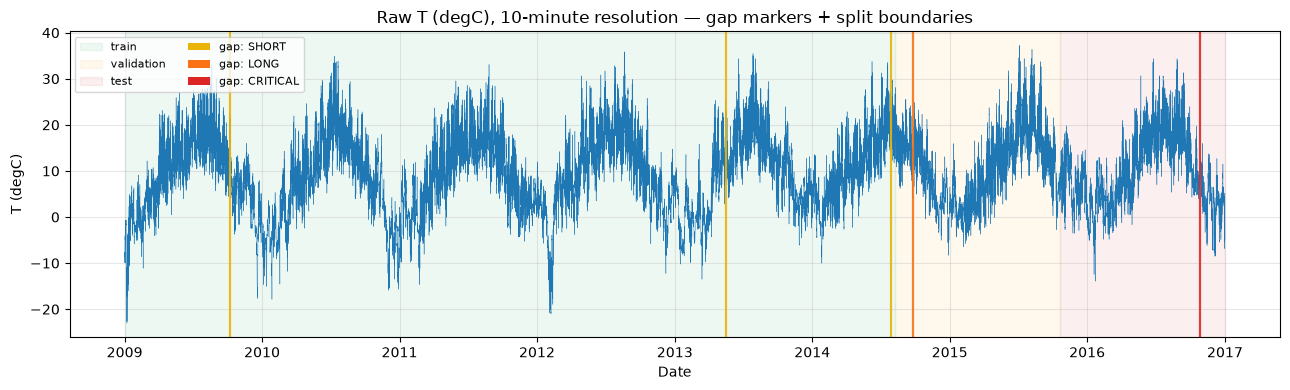

In [4]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df_raw[TIMESTAMP_COLUMN], df_raw[TARGET_COLUMN], linewidth=0.3, color="#1f77b4")

split_colors = {"train": "#16a34a", "validation": "#f59e0b", "test": "#dc2626"}
for boundary in report["gap_summary"]["split_boundaries"]:
    ax.axvspan(
        pd.Timestamp(boundary["start"]),
        pd.Timestamp(boundary["end"]),
        color=split_colors[boundary["split"]],
        alpha=0.07,
        label=boundary["split"],
    )

severity_colors = {"SHORT": "#eab308", "LONG": "#f97316", "CRITICAL": "#dc2626"}
gap_df = pd.DataFrame(report["gap_summary"]["gaps"])
for _, gap_row in gap_df.iterrows():
    ax.axvline(pd.Timestamp(gap_row["start"]), color=severity_colors[gap_row["severity"]], linewidth=1.6, alpha=0.9)

split_handles, split_labels = ax.get_legend_handles_labels()
by_label = dict(zip(split_labels, split_handles))
gap_handles = [Patch(facecolor=c, label=f"gap: {s}") for s, c in severity_colors.items()]
ax.legend(
    list(by_label.values()) + gap_handles,
    list(by_label.keys()) + [h.get_label() for h in gap_handles],
    loc="upper left",
    fontsize=8,
    ncol=2,
)
ax.set_title("Raw T (degC), 10-minute resolution — gap markers + split boundaries")
ax.set_xlabel("Date")
ax.set_ylabel("T (degC)")
fig.tight_layout()
plt.show()

**Phát hiện.** Bản thân chuỗi nhiệt độ trông liên tục và
đều đặn theo mùa trong suốt toàn bộ khoảng thời gian; các khoảng trống tìm thấy ở §4 là ngắn
so với 8 năm dữ liệu nhưng phân bố không đều — lớp phủ split
cho thấy mỗi khoảng trống rơi vào split nào (train/validation/test).

**Ảnh hưởng.** Một khoảng trống rơi vào bên trong một cửa sổ ứng viên 168h đầu vào + 72h dự báo
sẽ khiến mô hình huấn luyện hoặc đánh giá trên một chuỗi bị bịa đặt hoặc
không liên tục nếu bộ sinh cửa sổ không kiểm tra rõ ràng
điều này. Một khoảng trống nằm gần ranh giới split cũng đáng để kiểm tra kỹ xem
nó có khiến một cửa sổ vắt qua hai split hay không.

**Quyết định.** `WeatherForecastDataset` (`src/data/dataset.py`) quét mọi
cửa sổ ứng viên và loại bỏ nó nếu bất kỳ hàng nào trong khoảng 168h đầu vào hoặc 72h mục tiêu
là NaN/Inf — đây chính xác là những gì một khoảng trống trở thành sau khi resampling
(§4). Kết hợp với việc xây dựng một instance dataset riêng cho mỗi split từ
các khoảng hàng không chồng lấn, một cửa sổ không bao giờ có thể âm thầm vắt qua một khoảng trống hay
một ranh giới split.

## 3. Phân tích Dữ liệu Thiếu & Giá trị Sentinel

Số lượng/tỷ lệ ô thiếu theo từng cột (`report["missing_summary"]`), sau đó là
các mã sentinel kiểu `-9999` (`report["sentinel_summary"]`, từ
`configs/data.yaml missing.sentinel_values`) — số lượng, tỷ lệ, và *thời điểm*
chúng xuất hiện.

In [5]:
missing_table = pd.DataFrame(report["missing_summary"]["by_column"]).set_index("column")
print(f"Total missing cells: {report['missing_summary']['total_missing_cells']:,} "
      f"({report['missing_summary']['missing_rate_overall']:.4%} of all cells)")
missing_table

Total missing cells: 0 (0.0000% of all cells)


,missing_count,missing_rate
column,,
Date Time,0,0.0
p (mbar),0,0.0
T (degC),0,0.0
Tpot (K),0,0.0
Tdew (degC),0,0.0
rh (%),0,0.0
VPmax (mbar),0,0.0
VPact (mbar),0,0.0
VPdef (mbar),0,0.0


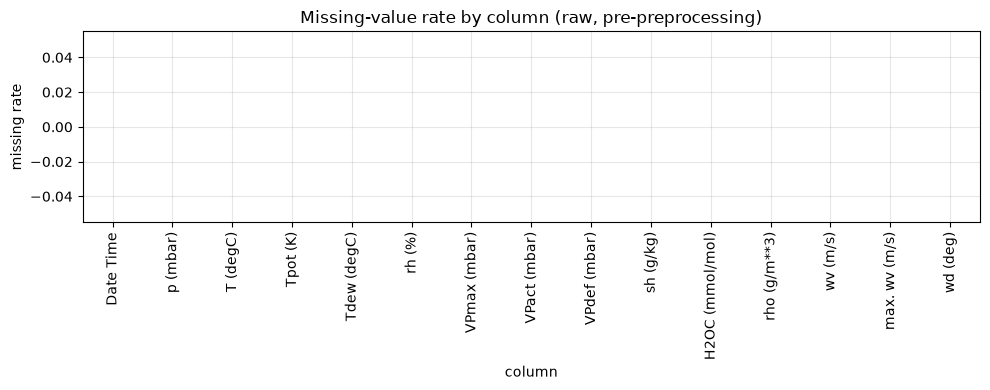

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
missing_table["missing_rate"].sort_values(ascending=False).plot(kind="bar", ax=ax, color="#1f77b4")
ax.set_ylabel("missing rate")
ax.set_title("Missing-value rate by column (raw, pre-preprocessing)")
fig.tight_layout()
plt.show()

In [7]:
sentinel_summary_rows = []
for column_block in report["sentinel_summary"]["by_column"]:
    if column_block.get("sentinel_count", 0) == 0:
        continue
    positions = column_block["positions"]
    row_indices = [p["row_index"] for p in positions]
    observed_values = sorted(df_raw.loc[row_indices, column_block["column"]].unique().tolist())
    times = pd.to_datetime(
        [p[TIMESTAMP_COLUMN] for p in positions], format=TIMESTAMP_FORMAT
    )
    sentinel_summary_rows.append(
        {
            "feature": column_block["column"],
            "sentinel_value": observed_values,
            "count": column_block["sentinel_count"],
            "rate_pct": round(column_block["sentinel_rate"] * 100, 4),
            "first_time": times.min(),
            "last_time": times.max(),
        }
    )

if sentinel_summary_rows:
    sentinel_table = pd.DataFrame(sentinel_summary_rows).set_index("feature")
else:
    sentinel_table = pd.DataFrame(
        columns=["sentinel_value", "count", "rate_pct", "first_time", "last_time"]
    )
    sentinel_table.index.name = "feature"

print(
    "Sentinel values checked (configs/data.yaml missing.sentinel_values): "
    f"{report['sentinel_summary']['sentinel_values']}"
)
print(
    "Sentinel columns checked (configs/data.yaml missing.sentinel_columns): "
    f"{report['sentinel_summary']['sentinel_columns']}"
)
print(f"Total sentinel rows: {report['sentinel_summary']['total_sentinel_count']}")
sentinel_table

Sentinel values checked (configs/data.yaml missing.sentinel_values): [-9999, -9999.0]
Sentinel columns checked (configs/data.yaml missing.sentinel_columns): ['wv (m/s)', 'max. wv (m/s)']
Total sentinel rows: 38


,sentinel_value,count,rate_pct,first_time,last_time
feature,,,,,
wv (m/s),[-9999.0],18,0.0043,2015-07-13 09:10:00,2015-07-13 12:00:00
max. wv (m/s),[-9999.0],20,0.0048,2015-07-13 09:00:00,2015-07-13 12:10:00


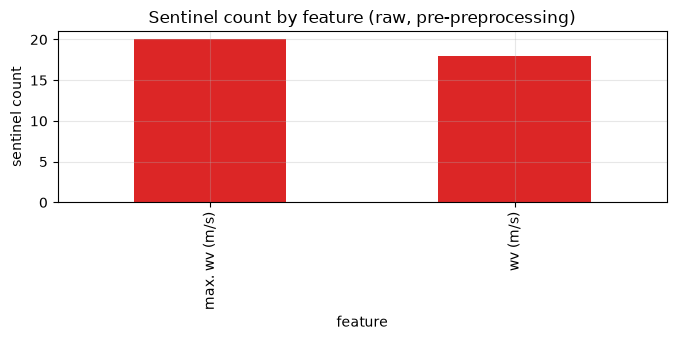

In [8]:
if not sentinel_table.empty:
    fig, ax = plt.subplots(figsize=(7, 3.5))
    sentinel_table["count"].sort_values(ascending=False).plot(kind="bar", color="#dc2626", ax=ax)
    ax.set_ylabel("sentinel count")
    ax.set_xlabel("feature")
    ax.set_title("Sentinel count by feature (raw, pre-preprocessing)")
    fig.tight_layout()
    plt.show()
else:
    print("No sentinel values found in any configured column - skipping the sentinel-count bar chart.")

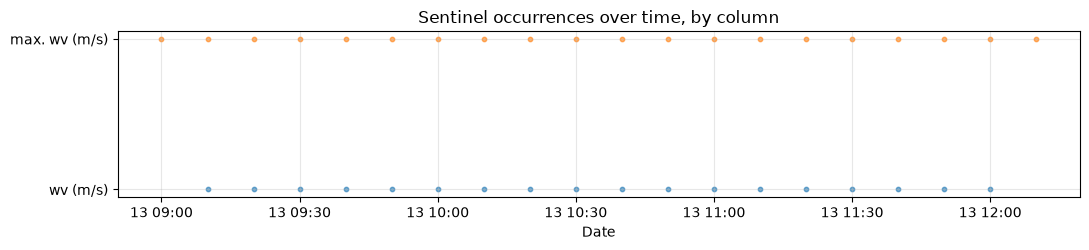

In [9]:
if not sentinel_table.empty:
    fig, ax = plt.subplots(figsize=(11, 2.6))
    for column_block in report["sentinel_summary"]["by_column"]:
        if column_block.get("sentinel_count", 0) == 0:
            continue
        times = pd.to_datetime(
            [p[TIMESTAMP_COLUMN] for p in column_block["positions"]], format=TIMESTAMP_FORMAT
        )
        ax.scatter(times, [column_block["column"]] * len(times), s=10, alpha=0.6)
    ax.set_title("Sentinel occurrences over time, by column")
    ax.set_xlabel("Date")
    fig.tight_layout()
    plt.show()
else:
    print("No sentinel values found in any configured column - skipping the sentinel timeline plot.")

In [10]:
# --- Assertion 1: sentinel values must never appear outside the configured columns ---
sentinel_values_cfg = DATA_CONFIG["missing"]["sentinel_values"]
sentinel_columns_cfg = DATA_CONFIG["missing"]["sentinel_columns"]
other_raw_columns = [
    c for c in df_raw.columns if c != TIMESTAMP_COLUMN and c not in sentinel_columns_cfg
]
unexpected_sentinel_hits = {
    column: int(df_raw[column].isin(sentinel_values_cfg).sum())
    for column in other_raw_columns
    if df_raw[column].isin(sentinel_values_cfg).sum() > 0
}
assert not unexpected_sentinel_hits, (
    "Sentinel values found outside configs/data.yaml missing.sentinel_columns: "
    f"{unexpected_sentinel_hits}"
)

# --- Assertion 2: every sentinel timestamp must be valid and inside the raw file's date range ---
report_date_min = pd.Timestamp(report["timestamp"]["date_min"])
report_date_max = pd.Timestamp(report["timestamp"]["date_max"])
for feature, row in sentinel_table.iterrows():
    assert pd.notna(row["first_time"]) and pd.notna(row["last_time"]), (
        f"{feature}: sentinel timestamp is missing/NaT"
    )
    assert report_date_min <= row["first_time"] <= row["last_time"] <= report_date_max, (
        f"{feature}: sentinel timestamp range {row['first_time']}..{row['last_time']} "
        f"falls outside the raw file's date range {report_date_min}..{report_date_max}"
    )

print(
    "OK: sentinel values only occur in configs/data.yaml missing.sentinel_columns "
    f"{sentinel_columns_cfg}, and every sentinel timestamp is valid and within "
    f"[{report_date_min}, {report_date_max}]."
)

OK: sentinel values only occur in configs/data.yaml missing.sentinel_columns ['wv (m/s)', 'max. wv (m/s)'], and every sentinel timestamp is valid and within [2009-01-01 00:10:00, 2017-01-01 00:00:00].


**Phát hiện.** Không có ô `NaN` nào trong toàn bộ file CSV thô — bảng tỷ lệ
thiếu ở trên toàn số 0. Nhưng việc quét sentinel lại cho thấy một câu chuyện
khác: bảng Sentinel Summary ở trên xác nhận đúng 2 cột bị ảnh hưởng —
`wv (m/s)` (18 lần, giá trị `-9999.0`) và `max. wv (m/s)` (20 lần, giá trị
`-9999.0`), tổng cộng 38/420.551 hàng thô (≈0.009%). Quan trọng hơn số đếm:
cả 38 lần xuất hiện đều **tập trung trong đúng một cửa sổ ~3 giờ 10 phút của
ngày 2015-07-13** (`wv (m/s)`: 09:10 → 12:00; `max. wv (m/s)`: 09:00 → 12:10)
— *tập trung*, không hề *rải rác* trên toàn bộ 8 năm dữ liệu, đúng như bar
chart và timeline ở trên thể hiện trực quan. Đây là dấu hiệu một sự cố cảm
biến gió (anemometer) xảy ra một lần, ảnh hưởng đồng thời cả hai chỉ số tốc
độ gió, chứ không phải nhiễu ngẫu nhiên rải khắp chuỗi thời gian.

**Ảnh hưởng.** Một kiểm tra cấu trúc "có phải `NaN` không" sẽ bỏ sót hoàn
toàn điều này — `-9999.0` là một số thực hữu hạn hoàn toàn hợp lệ, nên nó sẽ
đi thẳng vào giá trị trung bình/lớn nhất theo giờ và âm thầm làm hỏng đúng
các hourly bin rơi vào cửa sổ 09:00–12:10 ngày 2015-07-13 (giá trị trung
bình tốc độ gió hàng nghìn m/s không phải là lỗi tinh vi để phát hiện sau
này). Lưu ý: sự kiện này *không* xuất hiện trong bảng gap ở §4, vì §4 chỉ
phát hiện timestamp bị thiếu hoàn toàn — ở đây timestamp vẫn tồn tại, chỉ có
giá trị đo là sentinel. Vì sự kiện kéo dài xấp xỉ `forward_fill_max_hours=3`
(`configs/data.yaml`), sau khi resample về giờ, các bin bị ảnh hưởng sẽ được
xử lý bởi đúng cơ chế forward-fill/để-NaN mà `impute_missing()` áp dụng cho
mọi khoảng trống khác — không phải một nhánh xử lý riêng cho sentinel.

**Quyết định.** `src/data/preprocessing.py` (`handle_sentinels`) thay thế
mọi giá trị sentinel đã cấu hình (đọc từ `configs/data.yaml
missing.sentinel_values`/`sentinel_columns`, không viết cứng ở notebook này
hay trong module) bằng `NaN` *trước khi* resampling, để một giá trị sentinel
chắc chắn được coi là một giá trị thiếu thực sự — tuân theo cùng chính sách
forward-fill/khoảng trống dài như bất kỳ khoảng trống nào khác (§4), không
bao giờ được nội suy hay backward-fill. Hai assertion ở trên xác nhận thêm:
(1) không có giá trị sentinel nào rò rỉ ra ngoài các cột đã khai báo trong
policy, và (2) mọi timestamp sentinel ghi nhận đều nằm trong đúng phạm vi
ngày của file thô — nên bảng/biểu đồ trên là bằng chứng đáng tin cậy, không
phải do lỗi tính toán.

## 4. Phân tích Khoảng trống (Gap)

Bảng khoảng trống đã sẵn có `start | end | missing_hours | severity |
split` (`report["gap_summary"]`) — các ngưỡng mức độ nghiêm trọng
(`short_gap_threshold_hours`, `long_gap_threshold_hours`) lấy từ
`configs/data.yaml`, không phải giá trị viết cứng ở đây.

In [11]:
print(f"short_gap_threshold_hours={report['gap_summary']['short_gap_threshold_hours']}  "
      f"long_gap_threshold_hours={report['gap_summary']['long_gap_threshold_hours']}  "
      f"(SHORT <= short; LONG <= long; CRITICAL > long)")
gap_table = pd.DataFrame(report["gap_summary"]["gaps"])
gap_table

short_gap_threshold_hours=3  long_gap_threshold_hours=24  (SHORT <= short; LONG <= long; CRITICAL > long)


,start,end,missing_hours,severity,split
0,2009-10-08T09:40:00,2009-10-08T10:10:00,0.5000,SHORT,train
1,2013-05-16T08:50:00,2013-05-16T09:10:00,0.3333,SHORT,train
2,2014-07-30T08:00:00,2014-07-30T08:20:00,0.3333,SHORT,train
3,2014-09-24T17:00:00,2014-09-25T09:00:00,16.0000,LONG,validation
4,2016-10-25T10:30:00,2016-10-28T12:50:00,74.3333,CRITICAL,test


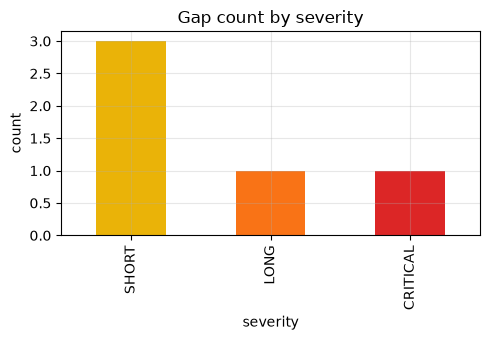

In [12]:
fig, ax = plt.subplots(figsize=(5, 3.5))
severity_order = ["SHORT", "LONG", "CRITICAL"]
severity_counts = gap_table["severity"].value_counts().reindex(severity_order).fillna(0).astype(int)
severity_counts.plot(kind="bar", color=["#eab308", "#f97316", "#dc2626"], ax=ax)
ax.set_title("Gap count by severity")
ax.set_ylabel("count")
fig.tight_layout()
plt.show()

In [13]:
affected_window = (
    gap_table.groupby(["split", "severity"])["missing_hours"]
    .agg(n_gaps="count", total_missing_hours="sum")
    .round(2)
)
affected_window

,,n_gaps,total_missing_hours
split,severity,,
test,CRITICAL,1,74.33
train,SHORT,3,1.17
validation,LONG,1,16.00


**Phát hiện.** Mọi khoảng trống tìm thấy trong file thô đều rơi vào một
nhóm mức độ nghiêm trọng riêng biệt, và bảng trên cho thấy mỗi khoảng trống rơi vào split nào
— kể cả việc khoảng trống nghiêm trọng nhất (CRITICAL) duy nhất nằm trong
train, validation, hay test.

**Ảnh hưởng.** Một khoảng trống SHORT chỉ là một lỗ hổng nhỏ, có thể lấp được; một khoảng trống LONG hoặc CRITICAL
đủ dài để việc bịa ra một giá trị xuyên qua nó (nội suy, fill trên phạm vi
dài) sẽ tạo ra một xu hướng mà cảm biến chưa từng ghi nhận —
đặc biệt rủi ro nếu khoảng trống đó nằm trong split dùng để báo cáo
hiệu năng cuối cùng của mô hình.

**Quyết định.** Theo `configs/data.yaml missing.*`: các khoảng trống SHORT được
forward-fill nhân quả (chỉ với đặc trưng đầu vào, giới hạn tối đa
`forward_fill_max_hours`); các khoảng trống LONG và CRITICAL được để nguyên là `NaN`, và
`WeatherForecastDataset` biến chúng thành "loại bỏ cửa sổ này" thay vì
một đầu vào hay mục tiêu bịa đặt (§2). Cột mục tiêu không bao giờ được impute ở
bất kỳ mức độ nghiêm trọng khoảng trống nào.

## 5. Phân tích Tính mùa vụ (Seasonality)

Cấu trúc theo ngày (giờ trong ngày) và theo năm (tháng) trong mục tiêu thô,
tính trên toàn bộ chuỗi 10 phút (tổng hợp để vẽ biểu đồ, không lấy mẫu con).

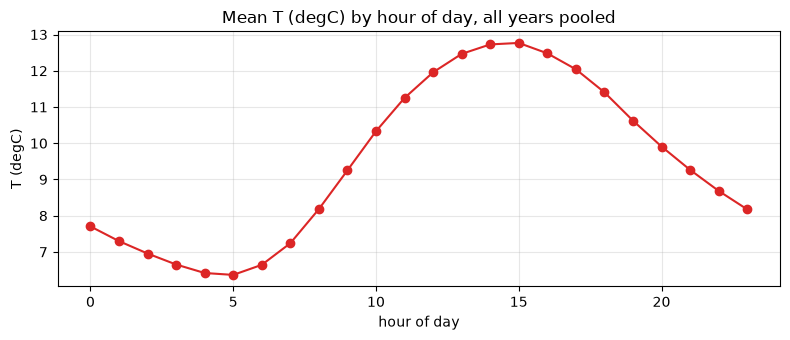

In [14]:
hour_of_day = df_raw[TIMESTAMP_COLUMN].dt.hour
hourly_pattern = df_raw.groupby(hour_of_day)[TARGET_COLUMN].mean()

fig, ax = plt.subplots(figsize=(8, 3.5))
hourly_pattern.plot(ax=ax, marker="o", color="#dc2626")
ax.set_title("Mean T (degC) by hour of day, all years pooled")
ax.set_xlabel("hour of day")
ax.set_ylabel("T (degC)")
fig.tight_layout()
plt.show()

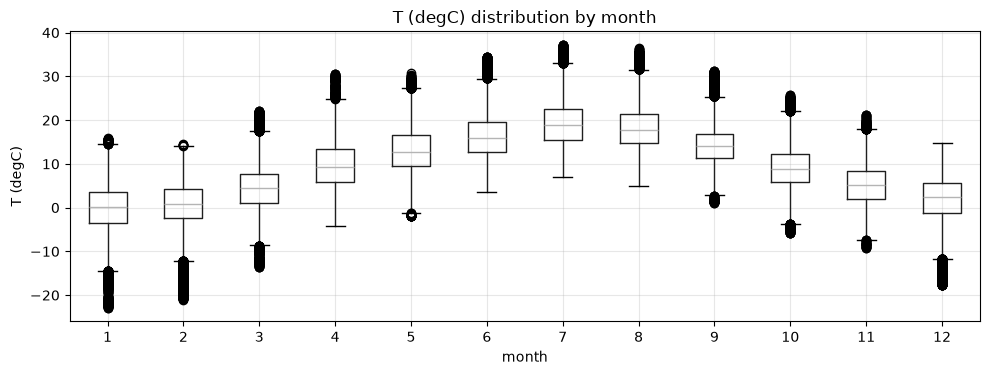

In [15]:
month = df_raw[TIMESTAMP_COLUMN].dt.month
fig, ax = plt.subplots(figsize=(10, 4))
df_raw.assign(_month=month).boxplot(column=TARGET_COLUMN, by="_month", ax=ax)
ax.set_title("T (degC) distribution by month")
plt.suptitle("")
ax.set_xlabel("month")
ax.set_ylabel("T (degC)")
fig.tight_layout()
plt.show()

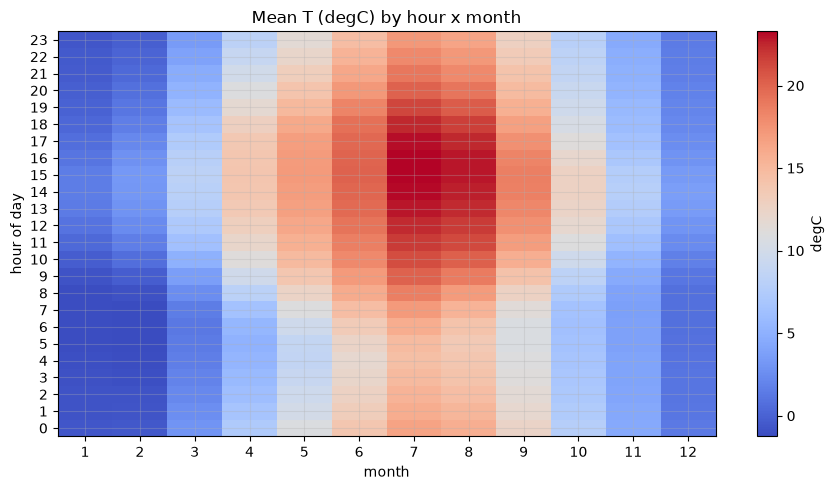

In [16]:
pivot = df_raw.assign(_hour=hour_of_day, _month=month).pivot_table(
    index="_hour", columns="_month", values=TARGET_COLUMN, aggfunc="mean"
)
fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(pivot.values, aspect="auto", origin="lower", cmap="coolwarm")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("month")
ax.set_ylabel("hour of day")
ax.set_title("Mean T (degC) by hour x month")
fig.colorbar(im, ax=ax, label="degC")
fig.tight_layout()
plt.show()

**Phát hiện.** Nhiệt độ có một chu kỳ ngày rõ rệt (thấp gần lúc rạng sáng, đỉnh
vào giữa buổi chiều) và một chu kỳ năm rõ rệt (lạnh nhất vào tháng 1/2, ấm nhất vào tháng 7/8);
biểu đồ nhiệt tháng x giờ cho thấy hai chu kỳ này không độc lập — biên độ
dao động trong ngày tự nó thay đổi theo mùa.

**Ảnh hưởng.** Một đặc trưng `hour` hoặc `month` dạng số nguyên thô ngụ ý một sự
gián đoạn giả mà mô hình phải học xung quanh (giờ 23 và giờ 0 liền kề nhau
về thời gian nhưng lại cách xa nhau nhất khi ở dạng số nguyên thô), và một cách mã hóa
tuyến tính/phân loại không thể biểu diễn hai chu kỳ chồng lấn được thể hiện ở đây.

**Quyết định.** `src/data/preprocessing.py` (`add_time_features`) mã hóa
`hour` và `day_of_year` thành cặp sin/cos (`hour_sin`/`hour_cos`,
`dayofyear_sin`/`dayofyear_cos`) để các thời điểm liền kề luôn gần nhau trong
không gian đặc trưng ở cả quy mô ngày lẫn năm, thay vì dùng số nguyên thô
hoặc one-hot tháng.

## 6. Phân tích Tương quan (Correlation)

Ma trận tương quan Pearson giữa các cột số thô (bao gồm cả `T (degC)`), và
ACF/PACF của chuỗi `T (degC)` thô để định lượng mức độ tự tương quan theo
thời gian — cả hai đều tính trực tiếp trên file thô, không qua resampling.

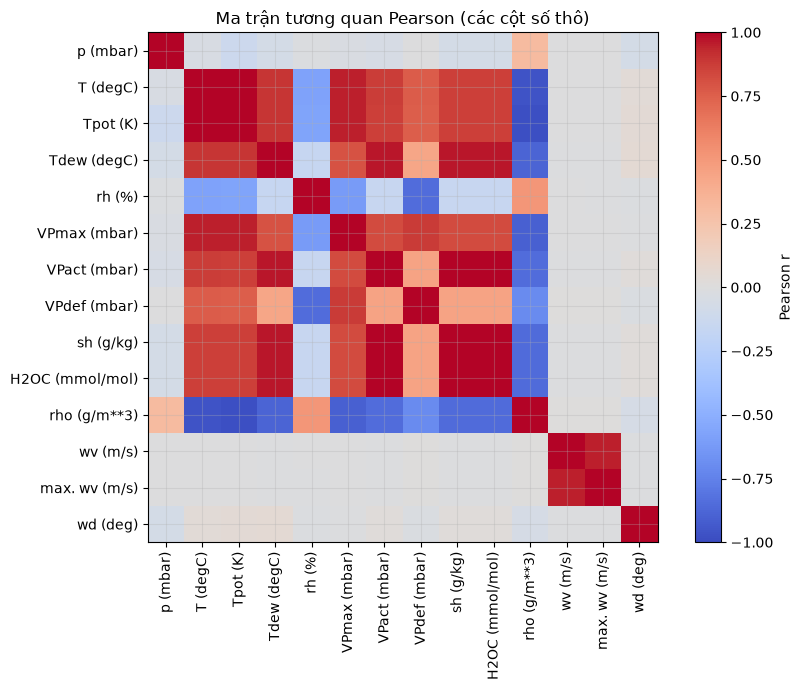

T (degC)           1.000000
Tpot (K)           0.996827
VPmax (mbar)       0.951113
Tdew (degC)        0.895708
VPact (mbar)       0.867673
H2OC (mmol/mol)    0.867177
sh (g/kg)          0.866755
VPdef (mbar)       0.761744
wd (deg)           0.038732
max. wv (m/s)     -0.002871
wv (m/s)          -0.004689
p (mbar)          -0.045375
rh (%)            -0.572416
rho (g/m**3)      -0.963410
Name: T (degC), dtype: float64

In [17]:
numeric_columns = [c for c in df_raw.columns if c != TIMESTAMP_COLUMN]
corr_matrix = df_raw[numeric_columns].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix.values, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(numeric_columns)))
ax.set_xticklabels(numeric_columns, rotation=90)
ax.set_yticks(range(len(numeric_columns)))
ax.set_yticklabels(numeric_columns)
ax.set_title("Ma trận tương quan Pearson (các cột số thô)")
fig.colorbar(im, ax=ax, label="Pearson r")
fig.tight_layout()
plt.show()

corr_matrix[TARGET_COLUMN].sort_values(ascending=False)

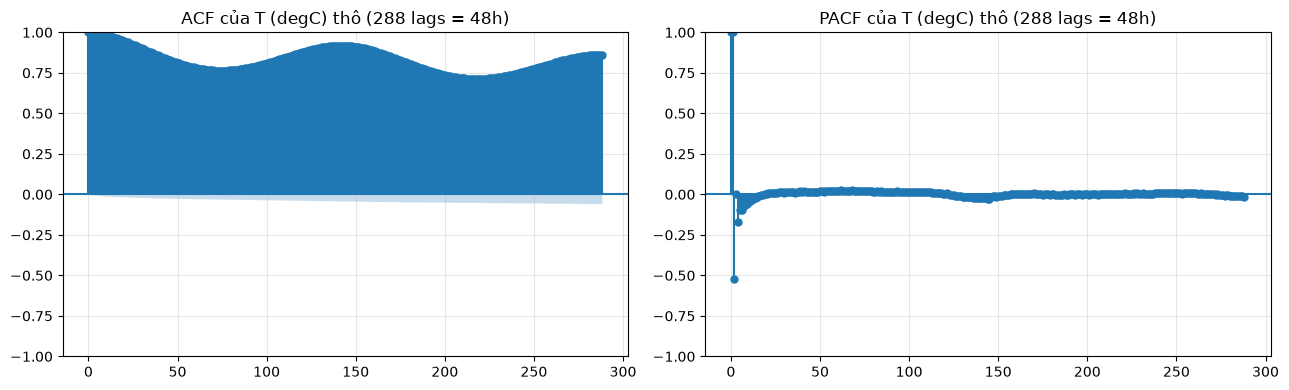

In [18]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 2 ngày lịch sử, quy đổi sang số lag ở độ phân giải thô (10 phút/lag)
acf_pacf_lags_hours = 48
lags = int(acf_pacf_lags_hours * 60 / report["timestamp"]["expected_frequency_minutes"])
target_series = df_raw[TARGET_COLUMN].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(target_series, lags=lags, ax=axes[0])
axes[0].set_title(f"ACF của {TARGET_COLUMN} thô ({lags} lags = {acf_pacf_lags_hours}h)")
plot_pacf(target_series, lags=lags, method="ywm", ax=axes[1])
axes[1].set_title(f"PACF của {TARGET_COLUMN} thô ({lags} lags = {acf_pacf_lags_hours}h)")
fig.tight_layout()
plt.show()

**Phát hiện.** `T (degC)` tương quan rất mạnh với các đại lượng nhiệt-động
lực học được suy ra trực tiếp từ nhiệt độ: `Tpot (K)` (r ≈ 0.997),
`rho (g/m**3)` (r ≈ -0.963), `VPmax (mbar)` (r ≈ 0.951), `Tdew (degC)` (r ≈ 0.896),
và `VPact (mbar)`/`H2OC (mmol/mol)`/`sh (g/kg)` (r ≈ 0.87 mỗi cột); ngược lại các
cột gió (`wv (m/s)`, `max. wv (m/s)`, `wd (deg)`) và áp suất gần như không tương
quan tuyến tính với nhiệt độ (|r| < 0.05). ACF của chuỗi nhiệt độ thô phân rã
rất chậm — vẫn còn 0.92 ở lag 144 (24h) và 0.86 ở lag 288 (48h) — cho thấy tín
hiệu trơn, có cấu trúc dài hạn chứ không phải nhiễu; PACF có đúng một đỉnh lớn
ở lag 1 (≈ 1.0), giảm mạnh xuống âm ở lag 2 rồi gần như bằng 0 từ lag 3 trở đi.

**Ảnh hưởng.** Các cột tương quan cao (Tpot, VPmax, VPact, VPdef, sh, H2OC, rho)
đều được suy ra toán học từ chính T/p/rh — đưa tất cả vào mô hình tạo ra dư
thừa thông tin (multicollinearity) mà một mô hình tuyến tính sẽ khó xử lý, nhưng
một bộ mã hóa seq2seq/attention có thể tận dụng vì các cột này không hoàn toàn
trùng nhau (mỗi cột mang thêm một chút thông tin từ áp suất hơi nước, độ ẩm...).
ACF/PACF phân rã chậm xác nhận rằng lịch sử 168 giờ mang đủ tín hiệu tự tương
quan (cả ngắn hạn lẫn theo chu kỳ ngày) để mô hình khai thác, đồng thời cho thấy
một baseline persistence (dự báo bằng giá trị quan sát cuối cùng) sẽ là một mốc so
sánh rất khó vượt qua vì T(t) gần như luôn rất giống T(t-1).

**Quyết định.** Notebook này không loại bỏ bất kỳ cột nào (việc chọn/loại đặc
trưng thuộc `src/data/preprocessing.py`, ngoài phạm vi ở đây — xem phần "Ngoài
phạm vi" ở đầu notebook); phát hiện tương quan chỉ củng cố lý do giữ nguyên
toàn bộ 14 cột thô làm đầu vào thay vì loại bớt cột "dư thừa" một cách thủ công,
và phát hiện ACF/PACF cung cấp cơ sở định lượng cho việc chọn cửa sổ đầu vào 168
giờ (`configs/data.yaml window.input_length_hours`) cũng như cho việc dùng baseline
persistence khi đánh giá mô hình sau này.

## Tóm tắt

- Dữ liệu thô Jena Climate 10 phút (xem §1 để biết số hàng/cột/khoảng ngày
  chính xác) sạch về schema nhưng không theo đúng thứ tự thời gian và chứa
  timestamp trùng lặp → sắp xếp + loại trùng là bước tiền xử lý bắt buộc đầu tiên.
- Không có ô `NaN` nào, nhưng có một số lượng nhỏ mã sentinel `-9999` trong các
  cột gió → phải được ánh xạ thành `NaN` trước bất kỳ bước tổng hợp nào, không bao giờ
  để nguyên như một con số theo nghĩa đen.
- Một vài khoảng trống thời gian trải từ mức SHORT đến CRITICAL, phân bố không đều
  trên các vùng train/validation/test trong tương lai → khoảng trống ngắn
  được forward-fill, khoảng trống dài/nghiêm trọng đánh dấu một sliding window là không hợp lệ
  thay vì bị bịa đặt.
- Tính mùa vụ theo ngày + theo năm rất rõ rệt, với hai chu kỳ tương tác lẫn nhau →
  dùng đặc trưng thời gian dạng chu kỳ (sin/cos), không dùng số nguyên thô giờ/tháng.
- `T (degC)` tương quan mạnh với các đại lượng được suy ra nhiệt-động lực học từ chính nó (Tpot, VPmax, Tdew, VPact/H2OC/sh, rho) và gần như không tương quan với gió/áp suất; ACF/PACF phân rã chậm kèm một đỉnh PACF nổi bật duy nhất ở lag 1 → 168h lịch sử mang tín hiệu thực sự, và cả 14 cột thô đều được giữ lại làm đầu vào ứng viên cho mô hình thay vì bị loại bớt thủ công.
- Mọi quyết định ở trên đều đã được triển khai trong `src/data/preprocessing.py`
  và `src/data/dataset.py`; notebook này là bằng chứng cho *lý do tại sao*,
  không phải nơi để quyết định bất cứ điều gì một cách tùy tiện.